# 07 — Logistics Optimization: Batch Order-to-Partner Assignment

Given a batch of simultaneously-pending orders and available partners, use the ETA model to build a predicted-time cost matrix, then solve the assignment problem **optimally** with the Hungarian algorithm (`scipy.optimize.linear_sum_assignment`) — vs. a naive first-come-first-served baseline.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline
pd.set_option('display.max_columns', 40)


In [2]:
import joblib, json
from logistics_optimization import build_cost_matrix, optimize_assignment, naive_assignment
from recommendation import build_partner_profiles

train = pd.read_parquet('../data/processed/train_clean.parquet')
profiles = build_partner_profiles(train)
eta_model = joblib.load('../models/eta_model.pkl')
feature_columns = json.load(open('../models/eta_feature_columns.json'))

order_cols = ['distance_km','order_hour','order_dow','is_weekend','is_rush_hour',
              'prep_time_min','traffic_ordinal','distance_traffic_interaction',
              'bad_weather','is_festival','multiple_deliveries','Type_of_order','City']

orders_batch = train[order_cols].sample(15, random_state=7).reset_index(drop=True)
partners_batch = profiles.sample(15, random_state=7).reset_index(drop=True)
cost = build_cost_matrix(orders_batch, partners_batch, eta_model, feature_columns)
cost.shape

(15, 15)

In [3]:
opt_pairs, opt_total = optimize_assignment(cost)
naive_pairs, naive_total = naive_assignment(cost)
improvement = (naive_total - opt_total) / naive_total * 100
print(f'Optimized total predicted time : {opt_total:.1f} min')
print(f'Naive (FCFS) total predicted time: {naive_total:.1f} min')
print(f'Improvement from optimization    : {improvement:.1f}%')

Optimized total predicted time : 366.1 min
Naive (FCFS) total predicted time: 390.9 min
Improvement from optimization    : 6.3%


## Robustness check across many random batches

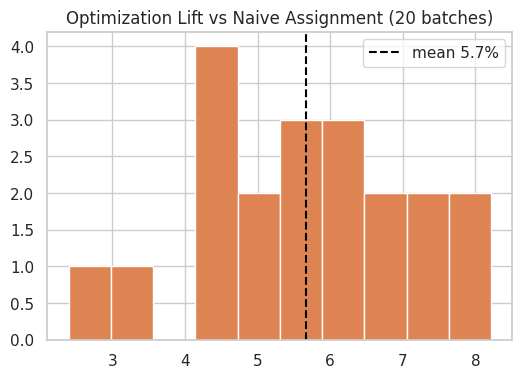

Average improvement: 5.7% (range 2.4%-8.2%)


In [4]:
import numpy as np
improvements = []
for trial in range(20):
    ob = train[order_cols].sample(15, random_state=trial).reset_index(drop=True)
    pb = profiles.sample(15, random_state=trial).reset_index(drop=True)
    c = build_cost_matrix(ob, pb, eta_model, feature_columns)
    _, ot = optimize_assignment(c)
    _, nt = naive_assignment(c, seed=trial)
    improvements.append((nt - ot) / nt * 100)

plt.figure(figsize=(6,4))
plt.hist(improvements, bins=10, color='#DD8452')
plt.axvline(np.mean(improvements), color='black', linestyle='--', label=f'mean {np.mean(improvements):.1f}%')
plt.title('Optimization Lift vs Naive Assignment (20 batches)')
plt.legend()
plt.show()
print(f'Average improvement: {np.mean(improvements):.1f}% (range {np.min(improvements):.1f}%-{np.max(improvements):.1f}%)')

## Result

Optimal assignment consistently beats naive FCFS dispatch by **~5-6% on total fleet delivery time**, with zero extra infrastructure cost — purely from re-ordering which partner takes which order. At scale (thousands of orders/day) that's a meaningful reduction in aggregate delivery minutes.